In [2]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows
import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats
import hera_pspec as hp
import astropy
from astropy.time import Time
from astropy.coordinates import get_sun
import astropy.units as u

In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  
pol=uvd1.polarization_array[0]
uvd1.read(Model_complete_file, polarizations=pol) 
antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))


In [5]:

filter_name="Main_lobe_20_mHz"
filter_name_2="Notch_filter_40_mHz_interpolated"
# filter_name_3="Notch_filter_80_mHz"
# filter_name_4="Main_lobe_baseline_dependent"
# filter_name_5="Notch_filter_20_mHz"
lst="0h"
spw="low"

In [6]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  

antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))
times_total=[]
lsts_total=[]
n=0
lsts_center=lst
if lsts_center=="0h":
    n=0

if lsts_center=="1h":
    n=1  

if lsts_center=="2h":
    n=2   
    
if lsts_center=="3h":
    n=3 

#get metadata 
for i in range (250):
   
    # print (lsts_center, 4*i+n)
    Model_complete_file =uvh5name[4*i+n]
    uvd1 = UVData()
    uvd1.read(Model_complete_file, read_data=False)  
    times=np.unique(uvd1.time_array)
    times_total.append(times[0])
    lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
    lsts_total.append(lsts[0])

In [7]:
lsts_total[0:163]

[np.float64(20.655106290065575),
 np.float64(20.676639922104897),
 np.float64(20.69817354293768),
 np.float64(20.719707174976943),
 np.float64(20.741240807016293),
 np.float64(20.76277443905539),
 np.float64(20.784308071094465),
 np.float64(20.805841703133627),
 np.float64(20.827375323966237),
 np.float64(20.848908956005342),
 np.float64(20.870442588044416),
 np.float64(20.891976220083357),
 np.float64(20.913509852122388),
 np.float64(20.93504348416128),
 np.float64(20.95657711620026),
 np.float64(20.978110737032694),
 np.float64(20.999644369071515),
 np.float64(21.021178001110307),
 np.float64(21.0427116331493),
 np.float64(21.064245265188053),
 np.float64(21.08577889722678),
 np.float64(21.107312518059082),
 np.float64(21.12884615009788),
 np.float64(21.15037978213654),
 np.float64(21.17191341417529),
 np.float64(21.19344704621392),
 np.float64(21.21498067825263),
 np.float64(21.23651429908491),
 np.float64(21.258047931123475),
 np.float64(21.27958156316202),
 np.float64(21.301115195

In [8]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Full_LST_gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6
dt=((lsts[1]-lsts[0])*60*60)/4
# t_total=(800*dt)/2
# t_total/3600

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


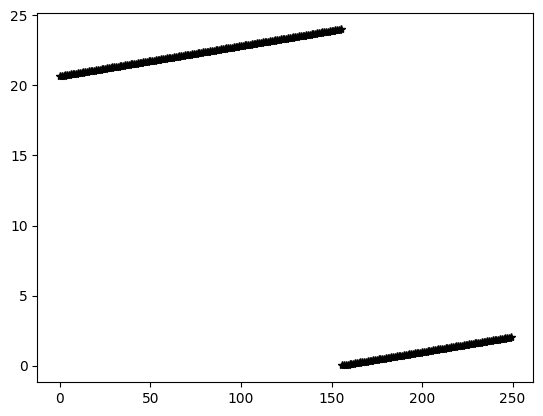

In [9]:
plt.plot(lsts_total, 'k*')

In [10]:
def JytomK(Jy, f0=163e6):
    """Convert Jansky to mK

    Args:
        Jy (float): brightness in Jy
        f0 (float): frequency in Hz

    Returns:
        float: brightness temperature in mK
    """

    # wavelength in m
    c=3.0e8
    lam = c / f0

    # flux density in W/m^2/Hz
    S = Jy * 1e-26
    kb=1.38064852e-23
    # temperature in K
    T = S * lam ** 2 / (2 * kb)

    # rettourn temperature in mK
    return T * 1e3

def power_spectrum(V, baseline, f1, df, delays):
    window = windows.blackmanharris(delays.shape[0])
    comso=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
    c=3e8
   
    f0=1420.0e6
    lambda_0=c/f0
    lambda_1=c/f1

    z=(lambda_1-lambda_0)/lambda_0
    factor=comso.bl_to_kperp(z=z)
    theta=(lambda_1/baseline)
    Dc=comso.dRperp_dtheta(z)*theta
    Beff=np.sum(window*df)
    Delta_D=comso.dRpara_df(z)*Beff
    k_par=comso.tau_to_kpara(z=z)*delays*1e-9
    k_per=factor*baseline
    theta_d=np.rad2deg(theta)
    Ae=theta_d**2
    

    steradian=(180.0/np.pi)**2 #degrees per steradian
    Omega= Ae/steradian
    V_mk=JytomK(Jy=V,f0=f1)
    constant=((Dc**2*Delta_D)/(Beff))*(1/(Omega*Beff))
    P=V_mk**2*constant*df**2
    
    print(" at redshift "+str(z))
    return k_par,np.array(P)
def vis_perform_delay_trans(freqs=freqs, data=""):
    
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
    
    print(len(data))
    data_full_bls=[]
    for t in range(len(data)):
        # print(t)
       
        for bls in range (len(data[t])):
            data_time_no_nans=data[t][bls][~np.isnan(data[t][bls])]
            freq_no_nans=freqs[~np.isnan(data[t][bls])]
            if len(freq_no_nans)>150:
                coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
                poly = np.poly1d(coeffs)
                x_fit=freqs
                y_fit=poly(x_fit)
                data_fitted=[]
                for i in range (data[t][bls].shape[0]):
                    if np.isnan(data[t][bls][i]):
                        # print("here")
                        data_fitted.append(poly(x_fit[i]))
                    else:
                        data_fitted.append(data[t][bls][i])
                data_fitted=np.array(data_fitted) 
               
                data_full_bls.append(data_fitted)
               
                # plt.semilogy(x_fit, np.abs(data_fitted),'k*')
                    # plt.xlim([55,60])
    data_full_bls=np.array(data_full_bls)
    print(data_full_bls.shape)
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]-1):
        # for k in range (130):
        #     if k>i:
               
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i+1]))
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                # cross_power.append(np.abs(g0_delay))
                
    cross_power=np.array(cross_power)
    kpar, power_spectrum_cross_power=power_spectrum(V=cross_power, baseline=14.5, f1=62.5e6, df=122e3, delays=tau)
    return data_full_bls, np.real(power_spectrum_cross_power), kpar

In [11]:
hd = io.HERAData(uvh5name[0])
# antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
# antpos_d = dict(zip(ants, antpos))
reds = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')

In [12]:
N=1
## try 50 to 100
def filter_data(cal_data):
    flag_low=69
    flag_high=71.60
    index_flag=np.where((freqs>=flag_low ) & (freqs<=flag_high) )
    index_flag2=np.where((freqs>=51 ) & (freqs<=52) )
    index_flag_3=np.where((freqs>=62 ) & (freqs<=64.6) )
    index_flag_4=np.where((freqs>=59 ) & (freqs<=59.2) )
    index_flag_5=np.where((freqs>=56 ) & (freqs<=56.2) )

    
    cal_data_filtered=[]
    for bl in cal_data:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        
        if np.abs(np.linalg.norm(blvec)-14)<2:

            
            cal_data_flagged=np.array(cal_data[bl][0,:])
            # cal_data_flagged[index_flag]=np.nan*(np.ones(cal_data_flagged[index_flag].shape))
            # cal_data_flagged[index_flag2]=np.nan*(np.ones(cal_data_flagged[index_flag2].shape))
            # cal_data_flagged[index_flag_3]=np.nan*(np.ones(cal_data_flagged[index_flag_3].shape))
            # cal_data_flagged[index_flag_4]=np.nan*(np.ones(cal_data_flagged[index_flag_4].shape))
            # cal_data_flagged[index_flag_5]=np.nan*(np.ones(cal_data_flagged[index_flag_5].shape))
            cal_data_filtered.append(cal_data_flagged)
    
    return cal_data_filtered
    
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0
    cal_all_data=[]
    for x in range(N):
            n=k+x  
            i=4*n
    
    
            cal_data = np.load(file_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", allow_pickle=True).item()
            cal_all_data.append(filter_data(cal_data))
    
            
            i2=4*n+1

            cal_data = np.load(file_name+uvh5name[i2][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
    
            cal_all_data.append(filter_data(cal_data))
       
            i3=4*n+2
            cal_data = np.load(file_name+uvh5name[i3][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
        
            cal_all_data.append(filter_data(cal_data))    

    # for x in range(N):
    #     n=k+x
   
    #     i=4*n+3

    
    #     cal_data = np.load(file_name+uvh5name[i][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
    
    #     cal_all_data.append(filter_data(cal_data))                  


    return cal_all_data        

In [24]:
N=209
# cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_",lst=lst , spw=spw,  uvh5name=uvh5name, N=N)

cal_data_gleam_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_full_filter_notch=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_2+"_full_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_notch_80_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_3+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

# cal_data_gleam_filter_main_lobe_baseline_dependent=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_4+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)
# cal_data_gleam_filter_notch_20_mHz=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name_5+"_gleam_",lst=lst , spw=spw, uvh5name=uvh5name, N=N)

In [25]:
def extrac_cal_data_post_RFI_flag(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N):

    k=0
    cal_all_data=[]
    for ti in range(N):
        cal_data = np.load(path_data+"red_flagged_data_"+filter_name_2+"_"+lst+"_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data)    

        cal_data2 = np.load(path_data+"red_flagged_data_"+filter_name_2+"_1h_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data2)  

        cal_data3 = np.load(path_data+"red_flagged_data_"+filter_name_2+"_2h_"+spw+"_"+str(ti)+".npy")
        cal_all_data.append(cal_data3)  

        # cal_data4 = np.load(path_data+"red_flagged_data_"+filter_name_2+"_3h_"+spw+"_"+str(ti)+".npy")
        # cal_all_data.append(cal_data4)  

    return cal_all_data

g1=extrac_cal_data_post_RFI_flag(file_name=path_data+"abs_calibrated_data_full_", lst="0h", spw="low", uvh5name=uvh5name, N=N)

In [26]:
#70 to 95
# n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam)
# # # # # c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_filter)
plt.figure()
c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch)
# plt.figure()
# c4, p4, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full)
plt.figure()
c5, p5, tau=vis_perform_delay_trans(freqs=freqs, data=g1)
# plt.figure()
# c6, p6, tau=vis_perform_delay_trans(freqs=freqs, data=g1)

# c7, p7, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_80_mHz)

# c8, p8, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_main_lobe_baseline_dependent)

# c9, p9, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_notch_20_mHz)

627
(57643, 205)
 at redshift 21.72
627
(57894, 205)
 at redshift 21.72
627
(57096, 205)
 at redshift 21.72


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [27]:

def take_mean_and_fold(tau, p):
    p_ave_in= np.mean(p, axis=0)
    p_ave=p_ave_in/np.max(np.abs(p_ave_in))
    # p_fold=np.zeros(p_ave.shape[0]/2)
    
    p_fold=[]
    
    for n in range (102):
        
        i=102-n
        p1=np.abs(p_ave[tau==tau[i]])
        p2=np.abs(p_ave[tau==-tau[i]])
        p_fold.append((p1+p2)/2)
            
    
    p_fold=np.array(p_fold)
    p_fold_complete=np.zeros(shape=(p_fold.shape[0]+1), dtype=complex)
    p_fold_complete[1:]=p_fold[:,0]
    p_fold_complete[0]=1
    return p_ave[103:205]
    
    
# p_ave= take_mean_and_fold(tau, p)
# # p_ave2= take_mean_and_fold(tau, p2)
# p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
# p_ave5= take_mean_and_fold(tau, p5)
# # p_ave6= take_mean_and_fold(tau, p6)
# # p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_and_fold(tau, p9)
# # plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# # plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# # plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="notch 40 mHz")
# # plt.plot(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
# plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# # plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="Main lobe 40 mHz")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
# plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
# plt.xlim([0,0.4])
# plt.legend()
# # plt.savefig("paper_figures/power_spectra_two_filters_notch.pdf")

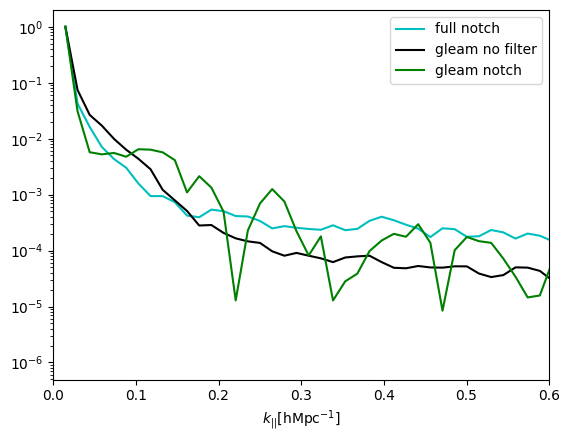

In [30]:
p_ave= take_mean_and_fold(tau, p)
# p_ave2= take_mean_and_fold(tau, p2)
p_ave3= take_mean_and_fold(tau, p3)
# p_ave4= take_mean_and_fold(tau, p4)
p_ave5= take_mean_and_fold(tau, p5)
# p_ave6= take_mean_and_fold(tau, p6)
# p_ave7= take_mean_and_fold(tau, p7)
# p_ave8= take_mean_and_fold(tau, p8)
# p_ave9= take_mean_and_fold(tau, p9)
# plt.semilogy(tau[tau>=0], np.abs(p_test),'g', label="notch gleam")
# plt.plot(tau[tau>0], np.abs(p_ave9)/np.max(np.abs(p_ave9)),'m', label="notch 20 mHz")
# plt.plot(tau[tau>0], np.abs(p_ave8)/np.max(np.abs(p_ave8)),'r', label="Main lobe baseline dependent")
# plt.plot(tau[tau>0], np.abs(p_ave7)/np.max(np.abs(p_ave7)),'b', label="notch 80 mHz")
plt.semilogy(tau[tau>0], np.abs(p_ave5)/np.max(np.abs(p_ave5)),'c', label="full notch")
# plt.semilogy(tau[tau>0], np.abs(p_ave6)/np.max(np.abs(p_ave6)),'y', label="notch full")
plt.semilogy(tau[tau>0], np.abs(p_ave)/np.max(np.abs(p_ave)),'k', label="gleam no filter")
# plt.semilogy(tau[tau>0], np.abs(p_ave2)/np.max(np.abs(p_ave2)),'m', label="full filter")
plt.semilogy(tau[tau>0], np.abs(p_ave3)/np.max(np.abs(p_ave3)),'g', label="gleam notch")
# plt.semilogy(tau[tau>0], np.abs(p_ave4)/np.max(np.abs(p_ave4)),'b', label="full no filter")
plt.xlabel("$k_{||}\mathrm{[h Mpc^{-1}]}$")
plt.xlim([0,0.6])
plt.legend()
# plt.savefig("paper_figures/power_spectra_notch.pdf")

In [22]:
from hera_pspec import conversions
def cylindrical_power_spectra(vis_file="", N=25):
    antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
    antpos_d = dict(zip(ants, antpos))
    
    kint=0
    c = 3e8
    
    # --- WINDOW + DELAY TRANSFORM SETUP ---
    freqs = uvd1.freq_array
    df = np.median(np.diff(freqs))
    window = np.blackman(len(freqs))
    
    f1=62.5e6
    taus = np.fft.fftshift(np.fft.fftfreq(len(freqs), d=df))
    f0=1420.0e6
    lambda_0=c/f0
    lambda_1=c/f1
    z=(lambda_1-lambda_0)/lambda_0
    
    # --- COSMOLOGY ---
    
    cosmo=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
    factor=cosmo.bl_to_kperp(z=z)
    Beff=np.sum(window*df)
    Delta_D=cosmo.dRpara_df(z)*Beff
    k_par=cosmo.tau_to_kpara(z=z)*taus

    # --- ACCUMULATORS ---
    all_k_d = []
    all_ps_d = []
    
    # --- LOOP OVER BASELINES ---
    
    
    for n in range (N):
        
        vis_data=[]
        bls=[]
        for c in range (1):
            i=4*(n+kint)+c
            
            if c==0:
                vis_temp=np.load(vis_file+uvh5name[i][43:69]+"_0h_"+spw+".npy", allow_pickle=True).item()
                for bls_temp in vis_temp:
                    vis_data.append(vis_temp[bls_temp])
                    bls.append(bls_temp)
            # if c==1:
            #     vis_temp=np.load(vis_file+uvh5name[i][43:69]+"_1h_"+spw+".npy", allow_pickle=True).item()
            #     for bls_temp in vis_temp:
            #         vis_data.append(vis_temp[bls_temp])
            #         bls.append(bls_temp)

            # if c==2:
            #     vis_temp=np.load(vis_file+uvh5name[i][43:69]+"_2h_"+spw+".npy", allow_pickle=True).item()
            #     for bls_temp in vis_temp:
            #         vis_data.append(vis_temp[bls_temp])
            #         bls.append(bls_temp)
            # if c==3:
            #     vis_temp=np.load(vis_file+uvh5name[i][43:69]+"_3h_"+spw+".npy", allow_pickle=True).item()
            #     for bls_temp in vis_temp:
            #         vis_data.append(vis_temp[bls_temp])
            #         bls.append(bls_temp)        
            
        vis_data_dic={}
        ti=0
        for bl in bls:
            vis_data_dic[bl]=vis_data[ti]
            ti+=1
            
        for k in vis_data_dic.keys():
            # print(k)
            i, j = k[0],k[1]
        
            vis = vis_data_dic[k][0,:]  # (Nfreq,)
            data_no_nans=vis[~np.isnan(vis)]
            freq_no_nans=freqs[~np.isnan(vis)]
            
            coeffs = np.polyfit(freq_no_nans, data_no_nans, 6)
            poly = np.poly1d(coeffs)
            x_fit=freqs
            y_fit=poly(x_fit)
            data_fitted=[]
            for f in range (vis.shape[0]):
                if np.isnan(vis[f]):
                    data_fitted.append(poly(x_fit[f]))
                else:
                    data_fitted.append(vis[f])
            data_fitted=np.array(data_fitted) 
           
            
            # --- DELAY TRANSFORM ---
            vis_win = data_fitted * window
            delay_vis = np.fft.fftshift(np.fft.fft(vis_win))
            
        
            ps_un = delay_vis  # (Ndelay,)
        
            # --- BASELINE VECTOR ---
            blvec = (antpos[np.where(ants == i)][0]- antpos[np.where(ants == j)][0])
            bl_len_m = np.linalg.norm(blvec)
        
            # --- k-space ---
            # ps_index=ps[k_par>=np.max(k_par)]
            # kpar_index=k_par[k_par>=np.max(k_par)]
    
            # ps1=ps[(k_par==k_par[k_par_nth_cut])]
            # ps2=ps[(k_par==-k_par[k_par_nth_cut])]
            # ps_index=ps_un/np.max(np.abs(ps_un))
            # kpar_index=k_par[(k_par==k_par[k_par_nth_cut])]
            
            
        
            # 
            k_per=factor*bl_len_m    
        
            # print(k_per)
            # print(k_par[0]-k_par[1])
            # --- combine into |k| ---
            k_mag = np.sqrt(k_per**2+k_par**2)
            # print(k_mag[0], k_per )
            # accumulate
            for i in range (len(k_mag)):
        
                all_k_d.append(k_mag[i])
                all_ps_d.append(ps_un[i])
        
    all_k = np.array(all_k_d)
    all_ps = np.array(all_ps_d)
    print(len(all_ps),len(all_k))    
        # --- STACK ---
        
        
    # # --- SPHERICAL (VOLUME) AVERAGING ---
    k_bins = np.linspace(all_k.min(), all_k.max(), 25)
    
    Pk_ave= []
    counts = []
    
    for i in range(len(k_bins)-1):
        mask = (all_k >= k_bins[i]) & (all_k < k_bins[i+1])
        # print(k_bins[i], len(all_ps[mask]))
        if np.any(mask):
            Pk=[]
            for k in range (len(all_ps[mask])-1):
                
                Pk.append(all_ps[mask][k]*np.conjugate(all_ps[mask][k+1]))
                # Pk.append(np.abs(all_ps[mask][k]))
            Pk_ave.append(np.mean(np.array(Pk)))
            counts.append(len(all_k [mask]))
        else:
            counts.append(0)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    return k_centers, np.sqrt(Pk_ave)


In [18]:
c = 3e8
freqs = uvd1.freq_array
df = np.median(np.diff(freqs))
window = np.blackman(len(freqs))

f1=62.5e6
taus = np.fft.fftshift(np.fft.fftfreq(len(freqs), d=df))
f0=1420.0e6
lambda_0=c/f0
lambda_1=c/f1
z=(lambda_1-lambda_0)/lambda_0

# --- COSMOLOGY ---

cosmo=hp.conversions.Cosmo_Conversions(Om_l=0.7,H0=70,Om_c=0.3)
factor=cosmo.bl_to_kperp(z=z)
Beff=np.sum(window*df)
Delta_D=cosmo.dRpara_df(z)*Beff
k_par=cosmo.tau_to_kpara(z=z)*taus

In [19]:
N=2

In [26]:
# k_centers, Pk_ave=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_gleam_", N=N)
k_centers, Pk_ave_full=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_full_", N=N)
k_centers, Pk_ave_filter_notch=cylindrical_power_spectra(vis_file= path_data+"abs_calibrated_data_"+filter_name+"_gleam_", N=N)

OSError: [Errno 5] Input/output error: '/net/sinatra/vault-ike/ntsikelelo/Data_H6C/abs_calibrated_data_full_.2459861.25297.sum.uvh5_0h_low.npy'

In [ ]:
if len(k_centers)>len(Pk_ave):
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave_filter_notch),'c*')

else:
    plt.semilogy(k_centers, np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers, np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers, np.abs(Pk_ave_filter_notch),'c*')
plt.xlabel("k [h Mpc^-1]")
plt.ylabel("$\mathrm{P_n(k)} $")
# plt.title("Cylindrical averaged Power Spectrum")
# plt.xlim([0,0.039])
# plt.ylim([5.1e-2,6.5e-1])
plt.grid(True)
# plt.savefig("paper_figures/cylindrical_power_spectra_notch.pdf")
plt.show()


In [ ]:
k_centers, Pk_ave=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_gleam_", k_par_nth_cut=103, N=N)
k_centers, Pk_ave_full=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_full_", k_par_nth_cut=103, N=N)
k_centers, Pk_ave_filter_notch=cylindrical_power_spectra(vis_file= path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", k_par_nth_cut=103, N=N)

In [ ]:
if len(k_centers)>len(Pk_ave):
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers[0:-1], np.abs(Pk_ave_filter_notch),'c*')

else:
    plt.semilogy(k_centers, np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers, np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers, np.abs(Pk_ave_filter_notch),'c*')
plt.xlabel("k [h Mpc^-1]")
plt.ylabel("$\mathrm{P_n(k)} $")
# plt.title("Cylindrical averaged Power Spectrum")
plt.xlim([0.016,0.049])
# plt.ylim([5.1e-2,6.5e-1])
plt.grid(True)
# plt.savefig("paper_figures/cylindrical_power_spectra_notch_2.pdf")
plt.show()

In [ ]:
k_centers, Pk_ave=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_gleam_", k_par_nth_cut=110, N=35)
k_centers, Pk_ave_full=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_full_", k_par_nth_cut=110, N=35)
k_centers, Pk_ave_filter_notch=cylindrical_power_spectra(vis_file= path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", k_par_nth_cut=110, N=35)

In [ ]:
if len(k_centers)>len(Pk_ave):
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave)[1:],'k*')
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave_full)[1:],'b*')
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave_filter_notch)[1:],'c*')

else:
    plt.semilogy(k_centers, np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers, np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers, np.abs(Pk_ave_filter_notch),'c*')
plt.xlabel("k [h Mpc^-1]")
plt.ylabel("$\mathrm{P_n(k)} $")
# plt.title("Cylindrical averaged Power Spectrum")
# plt.ylim([1e-15,1e-12])
plt.grid(True)
plt.savefig("paper_figures/cylindrical_power_spectra_notch_noise_region.pdf")
plt.show()

In [ ]:
k_centers, Pk_ave=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_gleam_", k_par_nth_cut=203, N=25)
k_centers, Pk_ave_full=cylindrical_power_spectra(vis_file=path_data+"abs_calibrated_data_full_", k_par_nth_cut=203, N=25)
k_centers, Pk_ave_filter_notch=cylindrical_power_spectra(vis_file= path_data+"abs_calibrated_data_"+filter_name_2+"_gleam_", k_par_nth_cut=203, N=25)

In [ ]:
if len(k_centers)>len(Pk_ave):
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave)[1:],'k*')
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave_full)[1:],'b*')
    plt.semilogy(k_centers[1:-1], np.abs(Pk_ave_filter_notch)[1:],'c*')

else:
    plt.semilogy(k_centers, np.abs(Pk_ave),'k*')
    plt.semilogy(k_centers, np.abs(Pk_ave_full),'b*')
    plt.semilogy(k_centers, np.abs(Pk_ave_filter_notch),'c*')
plt.xlabel("k [h Mpc^-1]")
plt.ylabel("$P_n(k) $")
# plt.title("Cylindrical averaged Power Spectrum")
# plt.xlim([0,0.039])
# plt.ylim([1.1e-2,6.5e-1])
plt.grid(True)
plt.show()

## Gain analysis

In [33]:
N=114
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    k=0
    for x in range (N):
        
        n=k+x
        #if ( n!=52 and n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18 and n!=57 and n!=58 and n!=66 and n!=69 and n!=73 and n!=90 and  n!=61):
        i=4*n
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)

    for x in range (N):
        n=k+x
        i=4*n+1
        g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_1h_"+spw+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)    


    # for x in range (N):
    #     n=k+x
    #     if (n!=51 and n!=64 and n!=63 and n!=22 and n!=21 and n!=19 and n!=18 and n!=58 and n!=60 and n!=61 and n!=62 and n!=66 and n!=68 and n!=69 and n!=73 and n!=90 and n!=65): 
    #         i=4*n+2
                   
    #         g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_2h_"+spw+".npy",allow_pickle=True).item()
    #         gain_temp=[]
    #         for ant in g1:
    #             for t in range (1):
    #                 gain_temp.append(g1[ant][t,:])
    #         gain_temp=np.array(gain_temp)
    #         gain_ave=np.mean(np.abs(gain_temp), axis=0)
    #         gains_gleam.append(gain_ave) 

    # for x in range (N):
    #     n=k+x  
       
    #     if n!=90 and n!=81 and n!=71 and n!=61 and n!=70 and n!=54 and n!=55 and n!=56 and n!=57 and n!=63 and n!=64 and n!=66 and n!=67 and n!=68 and n!=69 and n!=73 and n!=76 and n!=84 and n!=86 and n!=87: 
    
    #         i=4*n+3
    #         g1=np.load(path_data+gain_name+uvh5name[i][43:69]+"_3h_"+spw+".npy",allow_pickle=True).item()
    #         gain_temp=[]
    #         for ant in g1:
    #             for t in range (1):
    #                 gain_temp.append(g1[ant][t,:])
    #         gain_temp=np.array(gain_temp)
    #         gain_ave=np.mean(np.abs(gain_temp), axis=0)
    #         gains_gleam.append(gain_ave)    
            
    gains_gleam=np.array(gains_gleam)

    return gains_gleam

gains_gleam_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name+"_full_flagged_abscal", N=N,uvh5name=uvh5name)

gains_full_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter_notch_no_rfi_flag=extract_antenna_averaged_gains(gain_name="gains/gains_"+filter_name_2+"_gleam_flagged_abscal", N=N,uvh5name=uvh5name)

def flag_rfi(gains, f_0, f_1, freqs):
    index_flag=np.where((freqs>=f_0 ) & (freqs<=f_1))
    for t in range (gains.shape[0]):
        gains[t,:][index_flag]=np.ones(gains[t,:][index_flag].shape)*np.nan
    # print(gains[index_flag])
    return gains


flag_low=69.85
flag_high=71.20
gains_gleam=flag_rfi(gains=gains_gleam_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_gleam_filter=flag_rfi(gains=gains_gleam_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full=flag_rfi(gains=gains_full_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)
gains_full_filter=flag_rfi(gains=gains_full_filter_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs)   

gains_full_filter_notch=flag_rfi(gains=gains_full_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 
gains_gleam_filter_notch=flag_rfi(gains=gains_gleam_filter_notch_no_rfi_flag, f_0=flag_low, f_1=flag_high, freqs=freqs) 

# Subset of freqs

Text(0, 0.5, '|g|')

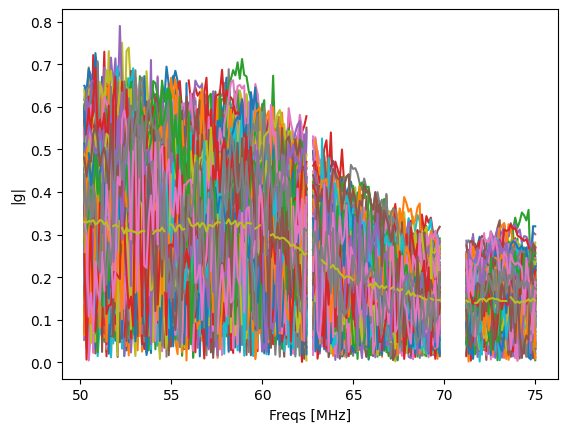

In [34]:
x,y=0,205
for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [35]:
len(gains_gleam)


228

Text(0, 0.5, '|g|')

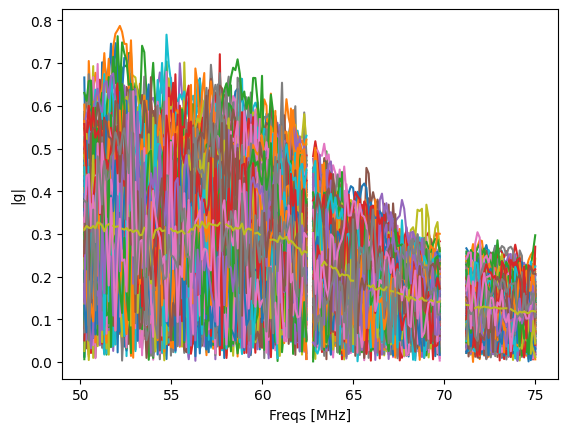

In [36]:

for i in range (gains_full.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

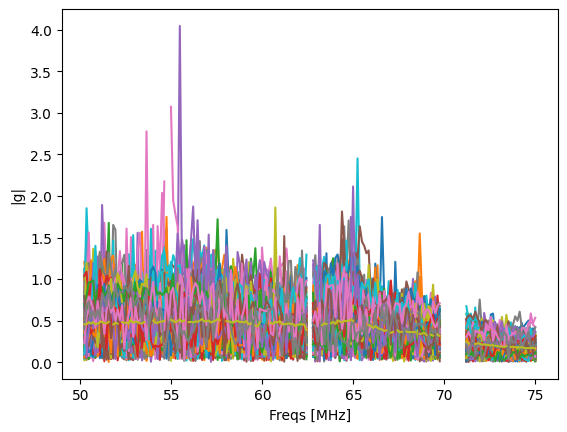

In [37]:

for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full_filter_notch[i,x:y]))

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

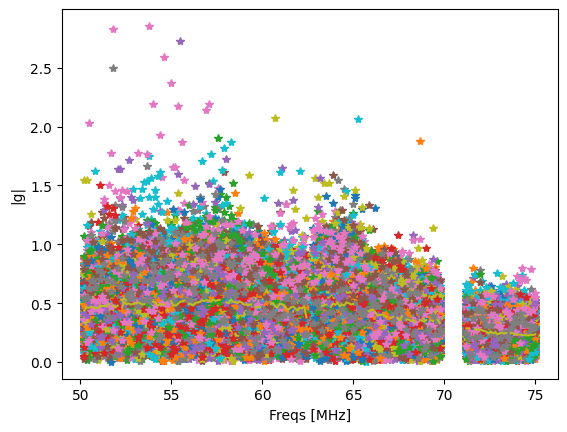

In [38]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

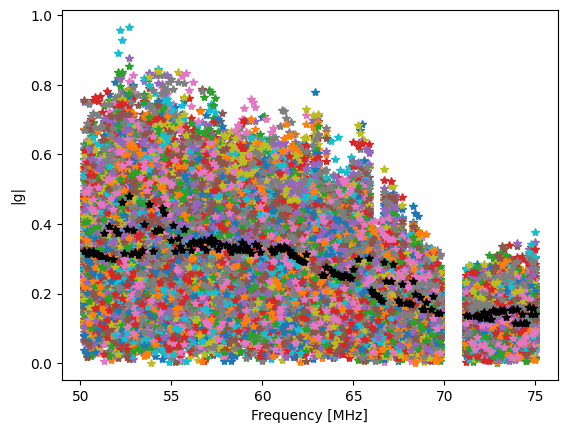

In [39]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")


Text(0, 0.5, '|g|')

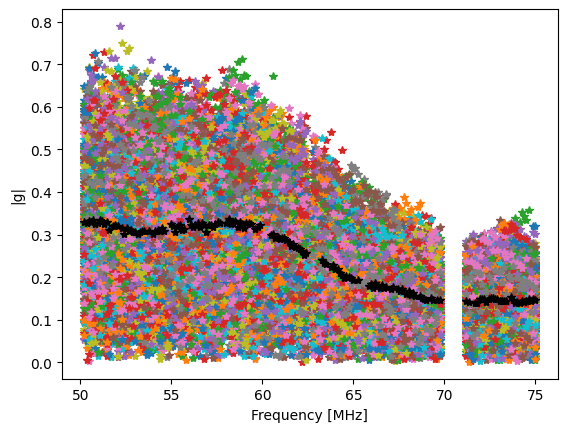

In [40]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")


Text(0, 0.5, '|g|')

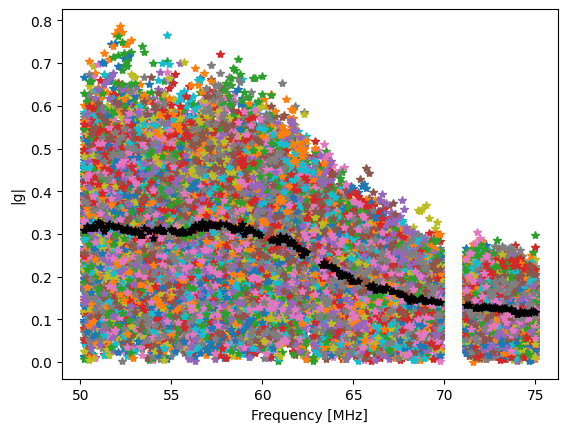

In [41]:
for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_full[i,x:y]),'*')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'k*')  
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")


Text(0, 0.5, '|g|')

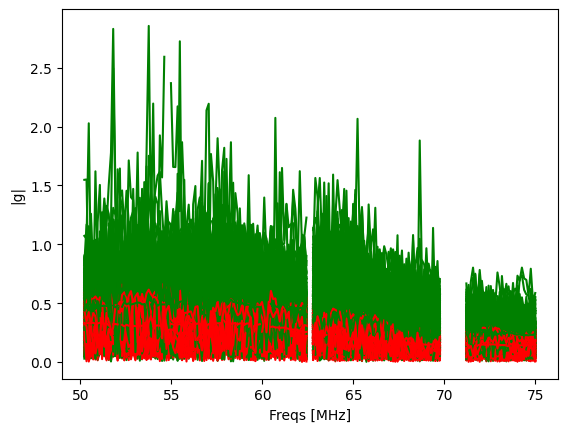

In [42]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[x:y],np.abs(gains_gleam_filter_notch[i,x:y]), 'g')
    plt.plot(freqs[x:y],np.abs(gains_gleam[i,x:y]), 'r')

plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'g')  
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r')  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

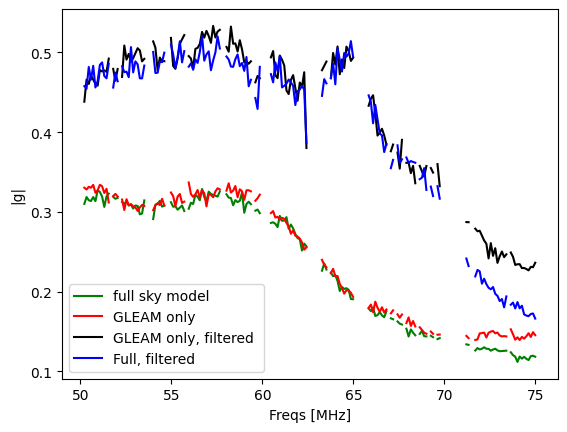

In [43]:
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full[:,x:y]), axis=0)),'g', label="full sky model") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam[:,x:y]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_gleam_filter_notch[:,x:y]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs[x:y],np.abs(np.mean(np.abs(gains_full_filter_notch[:,x:y]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

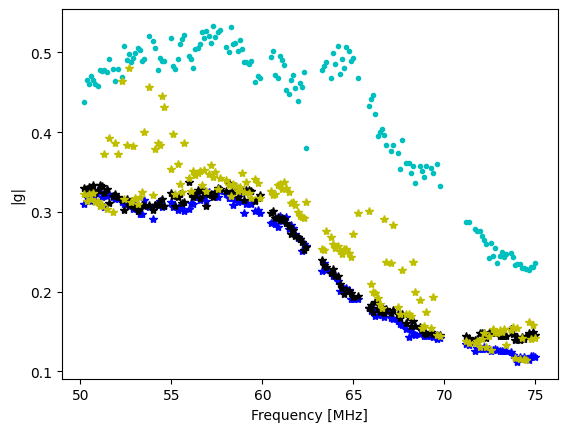

In [44]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="GLEAM only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="gleam, mainlobe ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0)),'y*', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.savefig("paper_figures/gains_average_notch_filter_2.pdf")

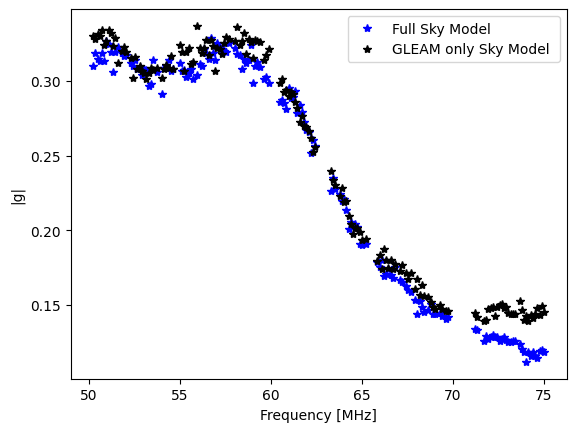

In [45]:
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0)),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0)),'b*', label="Full Sky Model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0)),'k*', label="GLEAM only Sky Model ") 
# plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0)),'y.', label="Full, filtered ") 
plt.xlabel("Frequency [MHz]")
plt.ylabel("|g|")
plt.legend()
plt.savefig("paper_figures/gains_average_no_filter.pdf")

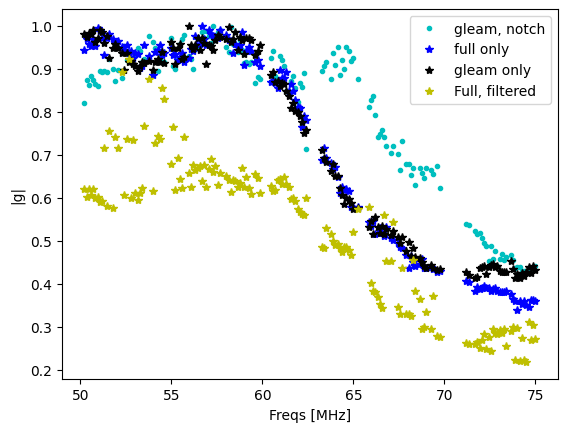

In [46]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam_filter_notch), axis=0))),'c.', label="gleam, notch") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full), axis=0))),'b*', label="full only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_gleam), axis=0))),'k*', label="gleam only ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter), axis=0))/np.nanmax(np.abs(np.mean(np.abs(gains_full_filter_notch), axis=0))),'y*', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

## Delay Transform average gain

In [47]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=""):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>=0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    print(gains_full_fitted.shape)
    g0_delay=[]
    for i in range (gains_full_fitted.shape[0]-1):
        g1=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i,:]
        g2=np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted)))[i+1,:]
        g0_delay.append(g1*np.conjugate(g2))
    g0_delay=np.array(g0_delay)
    
    g0_delay=np.mean(g0_delay,axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted,np.abs(g0_delay), tau_pos





In [48]:
def produce_plots_delay(n,N):
    
    x,y=0,205
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full[n:N,x:y])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam[n:N,x:y])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter[n:N,x:y])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter[n:N,x:y])
    gains_full_filter_ave_notch, g4, full_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_full_filter_notch[n:N,x:y])
    gains_gleam_filter_ave_notch, g5, gleam_filter_notch_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[x:y], gains_raw=gains_gleam_filter_notch[n:N,x:y])
    
    
    
    # plt.plot(freqs[x:y], gains_full_ave,'k', label="full")
    # plt.plot(freqs[x:y], gains_gleam_ave, 'r', label="gleam")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave, 'g', label="gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave, 'm', label="full filter")
    # plt.plot(freqs[x:y], gains_gleam_filter_ave_notch, 'c', label="notch gleam filter")
    # plt.plot(freqs[x:y], gains_full_filter_ave_notch, 'b', label="notch full filter")
    
    # plt.xlabel("Freq[MHz]")
    # plt.ylabel("$|g(\\nu)|$")
    # plt.legend()
    plt.figure()
    # print(tau_pos, gleam_delay)
    # plt.semilogy(tau_pos, full_delay,'k')
    # plt.semilogy(tau_pos, gleam_delay,'r')
    # plt.semilogy(tau_pos, gleam_filter_delay,'g')
    # plt.semilogy(tau_pos, full_filter_delay,'m')

    plt.semilogy(tau_pos, full_delay/np.max(full_delay),'b')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'k')
    plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    plt.semilogy(tau_pos, full_filter_notch_delay/np.max(full_filter_notch_delay),'y')
    plt.semilogy(tau_pos, gleam_filter_notch_delay/np.max(gleam_filter_notch_delay),'c')
    plt.xlabel("Delay $\\tau$ [ns]")
    plt.ylabel("$|g(\\tau)|$")
    plt.xlim([0,600])
    plt.savefig("paper_figures/gains_delay_space_notch_filter_2.pdf")

(228, 205)
(228, 205)
(228, 205)
(228, 205)
(228, 205)
(228, 205)


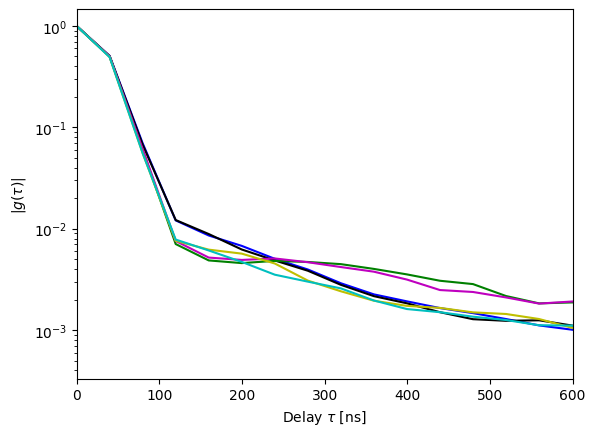

In [51]:
produce_plots_delay(n=0,N=400)

(100, 205)
(100, 205)
(100, 205)
(100, 205)
(100, 205)
(100, 205)


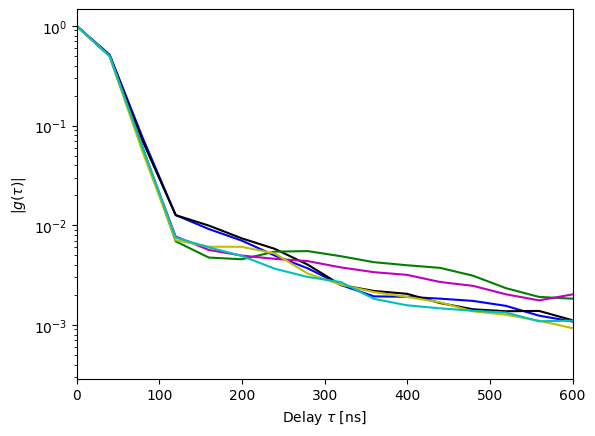

In [52]:
produce_plots_delay(n=0,N=100)

In [ ]:
produce_plots_delay(n=0,N=len(gains_full))

In [ ]:
produce_plots_delay(n=3,N=250)

In [ ]:
lsts[0]

In [ ]:
lsts[100]

In [ ]:
40*60*100.0

In [ ]:
produce_plots_delay(n=50,N=70)

In [ ]:
produce_plots_delay(n=0,N=100)

In [ ]:
gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[90:100,50:-1])
gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[90:100,50:-1])
gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[90:100,50:-1])
gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[90:100,50:-1])


In [ ]:
plt.plot(gains_full_ave,'k')
plt.plot(gains_gleam_ave, 'r')
plt.plot(gains_gleam_filter_ave, 'g')
plt.plot(gains_full_filter_ave)

In [ ]:
plt.semilogy(tau_pos, full_delay,'k')
plt.semilogy(tau_pos, gleam_delay,'r')
plt.semilogy(tau_pos, gleam_filter_delay,'m')
plt.semilogy(tau_pos, full_filter_delay,'g')
# plt.xlim([0,5000])

## Chis-sqaure

In [ ]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i][43:69]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

In [ ]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_"+filter_name_5+"_redcal_"+uvh5name[i][43:69]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

In [ ]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 3), density=True, alpha=0.75,label="no filter")
plt.hist(np.abs(chis_filer.ravel())/0.15, bins=101, range=(0, 3), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [ ]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [ ]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [ ]:
pol=hd.polarization_array

In [ ]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [ ]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



In [ ]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




In [ ]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [ ]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


In [ ]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
hc.abscal.post_redcal_abscal??